In [23]:
from astroquery.vizier import Vizier
import astropy.units as u
from astropy.table import Table ,vstack
from astropy.table import join
import matplotlib.pyplot as plt
from astropy.table import unique
import numpy as np
from astropy.io import fits
import scienceplots
import fitsio
import healpy as hp
import numpy as np
plt.style.use(['science', 'grid','notebook'])


In [5]:
north= fits.open('/user/animesh.sah/FP_CUTS/north_cuts_v10_flux_w1.fits')

data_north = north[1].data  


with fits.open("/user/animesh.sah/FP_CUTS/south_cuts_v10_flux_w1.fits", memmap=False) as hdul:
    hdul.info
    data_south = hdul[1].data

table_north = Table(data_north)
table_south = Table (data_south)

table_north_cut = table_north[table_north['DEC']>-30]
table_south_cut = table_south[table_south['DEC']>-30]

table = vstack([table_north_cut, table_south_cut])
#table

In [12]:
def flux_to_mag(flux,trans):
    frac = flux/trans
    mag = np.full_like(frac, np.nan,dtype=float)
    valid = frac > 0
    frac = frac[valid]
    mag[valid] = 22.5 - 2.5 * np.log10(frac)
    return mag

In [21]:
table_north_unique = unique(table_north, keys=['BRICKID', 'OBJID'])
table_south_unique = unique(table_south, keys=['BRICKID', 'OBJID'])
print(len(table_north_unique), len(table_south_unique) )
table = vstack([table_north_unique, table_south_unique])


143560 337336


In [22]:
unique_table = unique(table, keys=['BRICKID', 'OBJID'])

In [24]:
table_vizier_south = Table.read("../../FP_CUTS/south_cuts_vizier.fits", format="fits")
table_vizier_north = Table.read("../../FP_CUTS/north_cuts_vizier.fits", format="fits")


In [26]:
from astropy.coordinates import SkyCoord
import astropy.units as u
table_vizier_north = unique(table_vizier_north, keys=['BRICKID', 'OBJID','BRICKNAME'])
table_vizier_south = unique(table_vizier_south, keys=['BRICKID', 'OBJID','BRICKNAME'])


north_coords = SkyCoord(table_vizier_north['RA']*u.deg,table_vizier_north['DEC']*u.deg)
south_coords = SkyCoord(table_vizier_south['RA']*u.deg,table_vizier_south['DEC']*u.deg)

idx, d2d, d3d = north_coords.match_to_catalog_sky(south_coords)
max_sep = 10 * u.arcsec
sep_constraint = d2d < max_sep
north_matched = table_vizier_north[sep_constraint]
#north_matched = table_vizier_north[table_vizier_north['DEC'] > 30]
south_matched = table_vizier_south[idx[sep_constraint]]
#south_matched = table_vizier_south[table_vizier_south['DEC'] > 30]

In [27]:
table_vizier_matched=vstack([table_vizier_north,table_vizier_south])
print('length of total matched:',len(table_vizier_matched))

print('unique length of matched:',len(unique(table_vizier_matched, keys=['BRICKID', 'OBJID'])))



length of total matched: 439722
unique length of matched: 427273


In [28]:
from collections import OrderedDict
e1, e2 = table_vizier_matched['SHAPE_E1'], table_vizier_matched['SHAPE_E2']
epsilon = np.sqrt(e1**2 + e2**2)
bba = (1 - epsilon) / (1 + epsilon)
table_vizier_matched['bba'] = bba
# Define all individual cuts
cuts_dict = OrderedDict({
    'MAG_R < 18': table_vizier_matched['MAG_R'] < 18,
    'G - R > 0.68': (table_vizier_matched['MAG_G'] - table_vizier_matched['MAG_R']) > 0.68,
    'G - R > 1.3*(R - Z) - 0.05': (table_vizier_matched['MAG_G'] - table_vizier_matched['MAG_R']) > (1.3 * (table_vizier_matched['MAG_R'] - table_vizier_matched['MAG_Z']) - 0.05),
    'G - R < 2.0*(R - Z) - 0.15': (table_vizier_matched['MAG_G'] - table_vizier_matched['MAG_R']) < (2.0 * (table_vizier_matched['MAG_R'] - table_vizier_matched['MAG_Z']) - 0.15),
    'R_CIRC > 0': table_vizier_matched['R_CIRC'] > 0,
    '1 - bba < 0.7': (1 - table_vizier_matched['bba']) < 0.7,
    'Sérsic condition': ((table_vizier_matched['TYPE'] == 'SER') & (table_vizier_matched['SERSIC'] > 2.5)) | (table_vizier_matched['TYPE'] == 'DEV'),
    'Z_PHOT_MEDIAN < 0.15': table_vizier_matched['Z_PHOT_MEDIAN'] < 0.15,
    'Z_PHOT_L95 < 0.1': table_vizier_matched['Z_PHOT_L95'] < 0.1,
})

total = len(table_vizier_matched)
current_mask = np.ones(total, dtype=bool)
print(f"Initial: {total} rows")

for name, cond in cuts_dict.items():
    current_mask &= cond
    passed = np.count_nonzero(current_mask)
    print(f"After '{name}': {passed} rows (lost {total - passed})")

Initial: 439722 rows
After 'MAG_R < 18': 427707 rows (lost 12015)
After 'G - R > 0.68': 427560 rows (lost 12162)
After 'G - R > 1.3*(R - Z) - 0.05': 427451 rows (lost 12271)
After 'G - R < 2.0*(R - Z) - 0.15': 427301 rows (lost 12421)
After 'R_CIRC > 0': 427296 rows (lost 12426)
After '1 - bba < 0.7': 427296 rows (lost 12426)
After 'Sérsic condition': 427294 rows (lost 12428)
After 'Z_PHOT_MEDIAN < 0.15': 424373 rows (lost 15349)
After 'Z_PHOT_L95 < 0.1': 418126 rows (lost 21596)


In [29]:
total = len(table_vizier_matched)
current_mask = np.ones(total, dtype=bool)
previous_count = total

print(f"{'Step':<35} | {'Remaining':>9} | {'Lost':>6} | {'Cumulative Lost':>16}")
print("-" * 70)

cumulative_lost = 0
for name, cond in cuts_dict.items():
    current_mask &= cond
    current_count = np.count_nonzero(current_mask)
    step_lost = previous_count - current_count
    cumulative_lost += step_lost
    print(f"{name:<35} | {current_count:>9} | {step_lost:>6} | {cumulative_lost:>16}")
    previous_count = current_count

Step                                | Remaining |   Lost |  Cumulative Lost
----------------------------------------------------------------------
MAG_R < 18                          |    427707 |  12015 |            12015
G - R > 0.68                        |    427560 |    147 |            12162
G - R > 1.3*(R - Z) - 0.05          |    427451 |    109 |            12271
G - R < 2.0*(R - Z) - 0.15          |    427301 |    150 |            12421
R_CIRC > 0                          |    427296 |      5 |            12426
1 - bba < 0.7                       |    427296 |      0 |            12426
Sérsic condition                    |    427294 |      2 |            12428
Z_PHOT_MEDIAN < 0.15                |    424373 |   2921 |            15349
Z_PHOT_L95 < 0.1                    |    418126 |   6247 |            21596


In [ ]:

cuts = (
			(table_vizier_matched['MAG_R'] < 18) &
			((table_vizier_matched['MAG_G'] -table_vizier_matched['MAG_R']) > 0.68) &
			((table_vizier_matched['MAG_G']- table_vizier_matched['MAG_R']) > (1.3 * (table_vizier_matched['MAG_R'] - table_vizier_matched['MAG_Z']) - 0.05)) &
			((table_vizier_matched['MAG_G']- table_vizier_matched['MAG_R']) < (2.0 * (table_vizier_matched['MAG_R'] - table_vizier_matched['MAG_Z']) - 0.15)) &
			(table_vizier_matched['R_CIRC']> 0) &
			((1 -table_vizier_matched['bba']) < 0.7) &
			(((table_vizier_matched['TYPE'] == 'SER') & (table_vizier_matched['SERSIC'] > 2.5)) | (table_vizier_matched['TYPE'] == 'DEV')) &
			(table_vizier_matched['Z_PHOT_MEDIAN'] < 0.15) &
			(table_vizier_matched['Z_PHOT_L95'] < 0.1)
		)
table_vizier_matched[cuts]

unique_rows = unique(table_vizier_matched[cuts], keys=['BRICKID', 'OBJID'])
print(len(table_vizier_matched[cuts]), "rows after cuts")
print(len(unique_rows), "unique rows after FP cuts")
#unique_rows

#nonmask=~mask
#print(unique_rows[nonmask])

mask = ~np.any([col == -99 for col in unique_rows.itercols()], axis=0)
unique_rows = unique_rows[mask]
#mask = (unique_rows['Z_PHOT_MEDIAN'] != -99) & (unique_rows['Z_PHOT_L95'] != -99)
#unique_rows = unique_rows[mask]
#print(len(unique_rows), "rows after removing -99 values")
Mask_unique_rows=BGS_mask(unique_rows)
print('length after applying BGS cuts:',len(unique_rows[Mask_unique_rows]))
final_unique_rows=unique_rows[Mask_unique_rows]

418126 rows after cuts
418113 unique rows after FP cuts
length after applying BGS cuts: 417308


In [30]:
bad_mask = (
    (table_vizier_matched['Z_PHOT_MEDIAN'] == -99) |
    (table_vizier_matched['FLUX_G'] == 0) |
    (table_vizier_matched['FLUX_R'] == 0) |
    (table_vizier_matched['FLUX_Z'] == 0)
)
bad_table_vizier=table_vizier_matched[bad_mask]


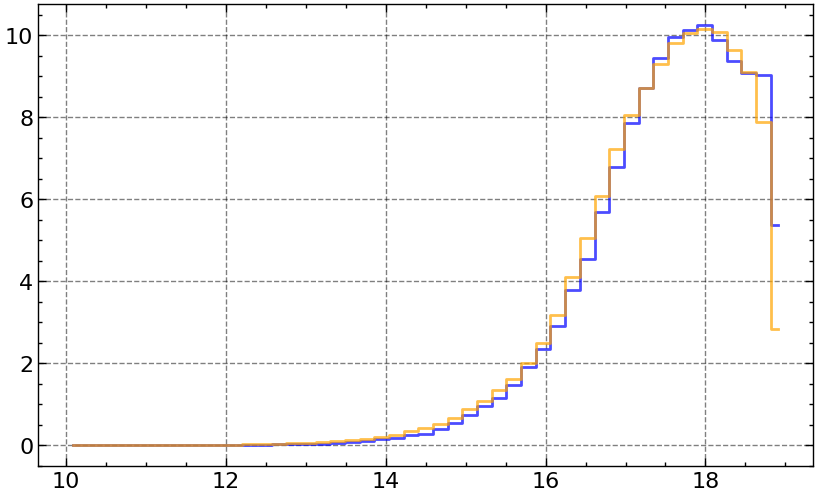

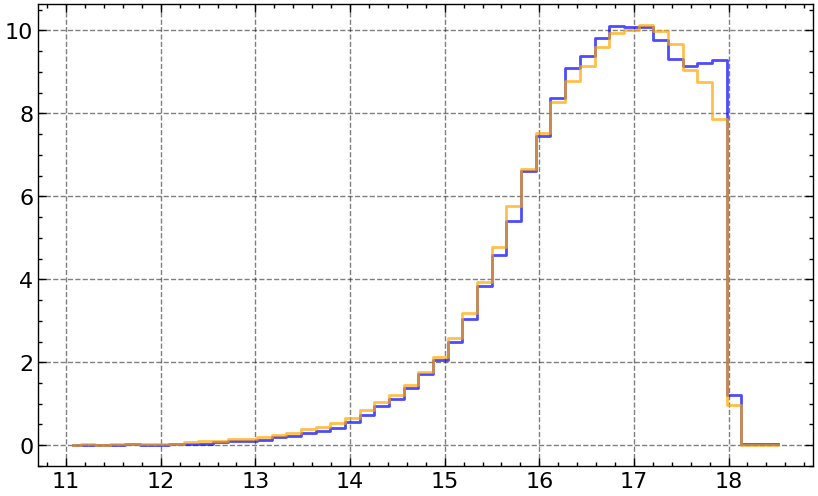

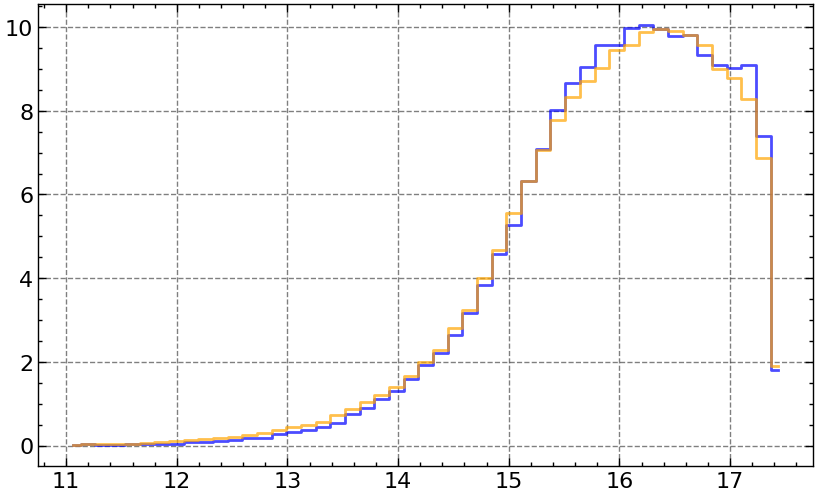

In [45]:
bands = ['G', 'R', 'Z']

for band in bands:
    if band =='R':
        bins_mag = np.linspace(11,18.6,50)
    elif band =='G':
        bins_mag = np.linspace(10,19,50)
    else:
        bins_mag = np.linspace(11,17.5,50)

    counts_vizier_north = np.histogram(table_vizier_north['MAG_' + band], bins=bins_mag)[0]
    counts_vizier_south = np.histogram(table_vizier_south['MAG_' + band], bins=bins_mag)[0]
    counts_selectes_north = np.histogram(table_north_unique['MAG_' + band], bins=bins_mag)[0]
    counts_selectes_south = np.histogram(table_south_unique['MAG_' + band], bins=bins_mag)[0]
    area_north=5167.3 
    area_south=12213.4
    plt.figure(figsize=(10, 6))
    bin_centers = (bins_mag[:-1] + bins_mag[1:]) / 2
    plt.step(bin_centers, counts_vizier_north / area_north/np.diff(bins_mag)[0], where='mid', label='Vizier North', color='blue', alpha=0.7)
    plt.step(bin_centers, counts_vizier_south / area_south/np.diff(bins_mag)[0], where='mid', label='Vizier South', color='orange', alpha=0.7)

    